In [13]:
import numpy as np
import pandas as pd

from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("Book1.csv")
df.columns = [c.replace("\n", " ").strip() for c in df.columns]

y = df["Median of NEES boxcox"].values.reshape(-1, 1)
X = df.drop(columns=["Median of NEES boxcox"])

Xs = StandardScaler().fit_transform(X)
ys = StandardScaler().fit_transform(y).ravel()

splitter = ShuffleSplit(n_splits=200, test_size=0.2, random_state=42)

rows = []
for n_comp in range(1, X.shape[1] + 1):
    r2s, rmses = [], []
    for tr, te in splitter.split(Xs):
        pls = PLSRegression(n_components=n_comp)
        pls.fit(Xs[tr], ys[tr])
        pred = pls.predict(Xs[te]).ravel()
        r2s.append(r2_score(ys[te], pred))
        rmses.append(np.sqrt(mean_squared_error(ys[te], pred)))
    rows.append([n_comp, np.mean(r2s), np.std(r2s), np.mean(rmses), np.std(rmses)])

cv_results = pd.DataFrame(
    rows,
    columns=["n_components", "R2_mean", "R2_sd", "RMSE_mean", "RMSE_sd"]
)
print(cv_results)


   n_components   R2_mean     R2_sd  RMSE_mean   RMSE_sd
0             1 -0.324449  1.134190   1.009180  0.179095
1             2 -0.360181  1.189026   1.020757  0.187074
2             3 -0.417767  1.236646   1.038519  0.194059
3             4 -0.621696  1.657522   1.090550  0.204778
4             5 -0.575239  1.483128   1.081645  0.208089
5             6 -0.533324  1.381573   1.071244  0.207371
6             7 -0.561462  1.412898   1.079922  0.207232
7             8 -0.653267  1.470281   1.114923  0.220917


In [14]:
pls = PLSRegression(n_components=2)
pls.fit(Xs, ys)

loadings = pd.DataFrame(
    pls.x_loadings_,
    index=features,
    columns=["PLS1", "PLS2"]
)

scores = pd.DataFrame(
    pls.x_scores_,
    columns=["PLS1_score", "PLS2_score"]
)

print(loadings.sort_values("PLS1", key=np.abs, ascending=False))


                           PLS1      PLS2
Hydrophobicity         0.630185 -0.029714
RK_Hydrophobic_ ratio -0.557279  0.315915
Hydrophobic  density   0.517283 -0.048135
STRK_ratio Log1p       0.240968  0.087028
Hydrophobic_ moment   -0.175101 -0.267914
Dfactor               -0.161675  0.697243
Netcharge             -0.130949  0.739868
Length                -0.121424 -0.099462


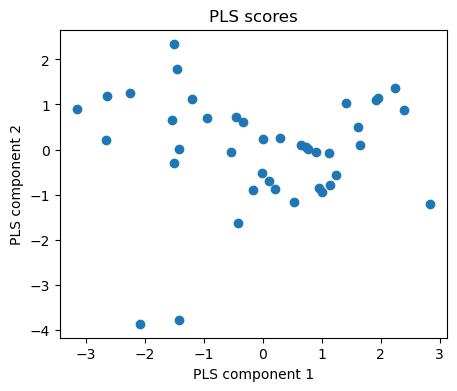

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.scatter(scores["PLS1_score"], scores["PLS2_score"])
plt.xlabel("PLS component 1")
plt.ylabel("PLS component 2")
plt.title("PLS scores")
plt.show()


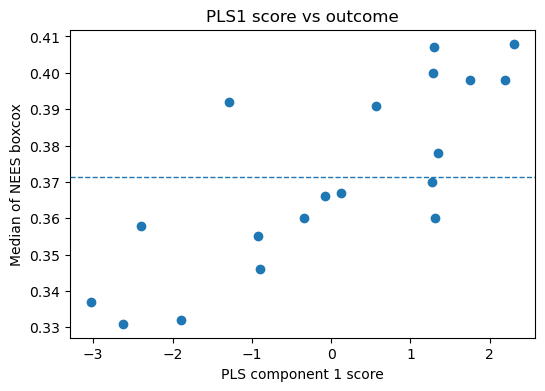

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler

# Load
df = pd.read_csv("Book2.csv")
df.columns = [c.replace("\n", " ").strip() for c in df.columns]

y = df["Median of NEES boxcox"].values.reshape(-1, 1)
X = df.drop(columns=["Median of NEES boxcox"])

# Standardize X (recommended for PLS)
Xs = StandardScaler().fit_transform(X)

# Fit 1-component PLS on the full dataset (for visualization)
pls1 = PLSRegression(n_components=1)
pls1.fit(Xs, y)

# PLS1 scores (latent variable values for each sample)
t1 = pls1.x_scores_[:, 0]

plt.figure(figsize=(6, 4))
plt.scatter(t1, y.ravel())
plt.xlabel("PLS component 1 score")
plt.ylabel("Median of NEES boxcox")
plt.title("PLS1 score vs outcome")
plt.axhline(np.mean(y), linestyle="--", linewidth=1)
plt.show()


In [26]:
df_output = pd.DataFrame({"PLS1_score": t1.ravel(), "Median of NEES boxcox": y.ravel()})
df_output.to_csv("pls1_scores.csv", index=False)

In-sample R² (NEES ~ PLS1): 0.6336171620401629


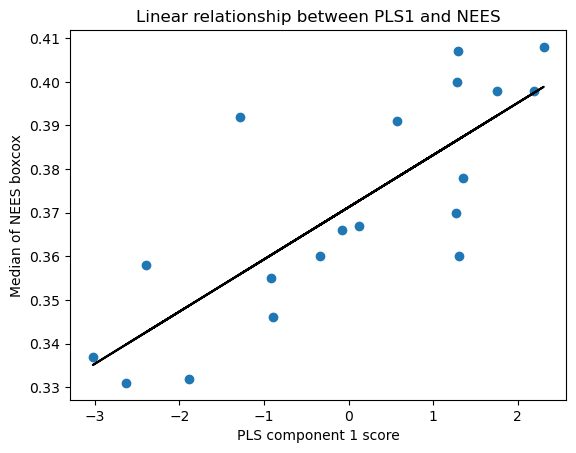

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv("Book2.csv")
df.columns = [c.replace("\n", " ").strip() for c in df.columns]

y = df["Median of NEES boxcox"].values
X = df.drop(columns=["Median of NEES boxcox"])

# Standardize X
Xs = StandardScaler().fit_transform(X)

# Fit 1-component PLS
pls1 = PLSRegression(n_components=1)
pls1.fit(Xs, y)

# Extract PLS1 scores
t1 = pls1.x_scores_[:, 0].reshape(-1, 1)

# Linear regression: NEES ~ PLS1
lm = LinearRegression().fit(t1, y)
yhat = lm.predict(t1)

r2_pls1 = r2_score(y, yhat)
print("In-sample R² (NEES ~ PLS1):", r2_pls1)

# Plot
plt.scatter(t1, y)
plt.plot(t1, yhat, color="black")
plt.xlabel("PLS component 1 score")
plt.ylabel("Median of NEES boxcox")
plt.title("Linear relationship between PLS1 and NEES")
plt.show()


In [29]:
r2_single = {}
for col in X.columns:
    lm = LinearRegression().fit(X[[col]], y)
    r2_single[col] = r2_score(y, lm.predict(X[[col]]))

r2_single = pd.Series(r2_single).sort_values(ascending=False)
print(r2_single)


Hydrophobicity                0.651510
Hydrophobic  density          0.477502
RK_Hydrophobic ratio Log1p    0.393877
STRK_ratio Log1p              0.074848
Length                        0.066224
Netcharge                     0.048879
Hydrophobic_ moment           0.037695
Dfactor                       0.035952
dtype: float64


In [33]:
import pandas as pd
import numpy as np
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv("Book1.csv")
df.columns = [c.replace("\n", " ").strip() for c in df.columns]

y = df["Median of NEES boxcox"].values.reshape(-1, 1)
X = df.drop(columns=["Median of NEES boxcox"])
features = X.columns

# Standardize predictors
Xs = StandardScaler().fit_transform(X)

# Fit 1-component PLS
pls1 = PLSRegression(n_components=1)
pls1.fit(Xs, y)

# Extract X loadings for component 1
loadings = pd.Series(
    pls1.x_loadings_[:, 0],
    index=features,
    name="PLS1_loading"
)

# Sort by absolute magnitude
loadings_sorted = loadings.reindex(loadings.abs().sort_values(ascending=False).index)

print(loadings_sorted)

# Save loadings to CSV
loadings_sorted.to_csv("pls1_loadings_all.csv", header=True)


Hydrophobicity                            0.596525
PositiveCharge_Hydrophobic_ratio Log1p   -0.591526
Hydrophobic  density                      0.465299
STRK_ratio Log1p                          0.321257
Dfactor                                  -0.212490
Netcharge                                -0.182543
Hhydrophobic_ moment                     -0.168761
Length                                   -0.069469
Name: PLS1_loading, dtype: float64
